# Cancer RNA-Seq Classification
## STAT 654 Machine Learning Course Project

This notebook implements the full pipeline for classifying RNA-seq gene expression profiles into one of five cancer types (BRCA, KIRC, LUAD, COAD, PRAD).

**Pipeline:**
1. **Section 1** — Data Cleaning & Exploratory Data Analysis
2. **Section 2** — Feature Engineering & Selection (ANOVA, BH-FDR, η², Kruskal-Wallis, PCA)
3. **Section 3** — Model Training & Evaluation (8 classifiers, hyperparameter tuning)

Every random operation uses `RNG = 42` for reproducibility.


---
# SECTION 1 — Data Cleaning & EDA

**Goal:** Load the TCGA Pan-Cancer RNA-seq dataset, perform quality checks, remove uninformative genes (constant / near-constant), and produce exploratory visualizations.

**Inputs:** Raw `data.csv` (801 × 20,531 expressions) and `labels.csv` (801 × tumor_class) from Kaggle.

**Outputs:** `cleaned_features.csv`, `cleaned_labels.csv`, `eda_summary.json`, `eda_outputs/*.png`.

### Cleaning methodology
- **Constant genes** (variance = 0) — dropped, they contribute nothing to any classifier.
- **Near-constant genes** (variance < 0.001) — dropped, effectively constant at the precision of log2(RSEM+1).
- **Outliers** — retained. RNA-seq outliers frequently encode real biological signal (e.g. genes massively over-expressed in one tumor subtype).


In [1]:
# 1.1 — Imports
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 100
RNG = 42

print('Libraries imported')


Libraries imported


In [2]:
# 1.2 — Load raw data (Kaggle auto-download, falls back to local files)
def load_raw():
    try:
        import kagglehub
        handle = 'waalbannyantudre/gene-expression-cancer-rna-seq-donated-on-682016'
        ds_dir = Path(kagglehub.dataset_download(handle))
        csvs = {p.stem.lower(): p for p in ds_dir.rglob('*.csv')}
        return pd.read_csv(csvs['data']), pd.read_csv(csvs['labels'])
    except Exception as e:
        print(f'Kaggle download failed ({e}); trying local data/ folder')
        local = Path('data')
        return pd.read_csv(local / 'data.csv'), pd.read_csv(local / 'labels.csv')

features_raw, labels_raw = load_raw()
features_raw = features_raw.rename(columns={'Unnamed: 0': 'sample_id'})
labels_raw = labels_raw.rename(columns={'Unnamed: 0': 'sample_id', 'Class': 'tumor_class'})

print(f'features: {features_raw.shape}')
print(f'labels:   {labels_raw.shape}')
features_raw.head(3)


features: (801, 20532)
labels:   (801, 2)


,sample_id,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0


In [3]:
# 1.3 — Merge & verify alignment
assert (features_raw['sample_id'].values == labels_raw['sample_id'].values).all(), 'sample IDs misaligned'
df = features_raw.merge(labels_raw, on='sample_id').set_index('sample_id')

target_col = 'tumor_class'
gene_cols = [c for c in df.columns if c != target_col]
X_all = df[gene_cols]
y = df[target_col]

print(f'merged: {df.shape}  ({X_all.shape[1]:,} genes, {len(y.unique())} classes)')


merged: (801, 20532)  (20,531 genes, 5 classes)


In [4]:
# 1.4 — Quality checks
missing_total = int(X_all.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())
all_numeric = X_all.dtypes.apply(lambda t: np.issubdtype(t, np.number)).all()

print(f'missing values:     {missing_total}')
print(f'duplicate rows:     {duplicate_rows}')
print(f'all numeric dtypes: {all_numeric}')
print(f'value range:        [{X_all.values.min():.3f}, {X_all.values.max():.3f}]  (log2(RSEM+1))')
print()
print('class counts:')
print(y.value_counts().sort_index())
imbalance_ratio = float(y.value_counts().max() / y.value_counts().min())
print(f'imbalance ratio (max/min): {imbalance_ratio:.2f}')


missing values:     0
duplicate rows:     0
all numeric dtypes: True
value range:        [0.000, 20.779]  (log2(RSEM+1))

class counts:
tumor_class
BRCA    300
COAD     78
KIRC    146
LUAD    141
PRAD    136
Name: count, dtype: int64
imbalance ratio (max/min): 3.85


In [5]:
# 1.5 — Remove constant & near-constant genes
gene_var = X_all.var()
constant_genes = gene_var[gene_var == 0].index.tolist()
low_var_genes = gene_var[(gene_var > 0) & (gene_var < 0.001)].index.tolist()
genes_to_remove = set(constant_genes) | set(low_var_genes)

X = X_all.drop(columns=list(genes_to_remove))

print(f'constant genes removed:        {len(constant_genes)}')
print(f'near-constant genes removed:   {len(low_var_genes)}')
print(f'final feature matrix:          {X.shape}')
print(f'retention rate:                {X.shape[1] / X_all.shape[1] * 100:.1f}%')


constant genes removed:        267
near-constant genes removed:   43
final feature matrix:          (801, 20221)
retention rate:                98.5%


In [6]:
# 1.6 — Outlier analysis (kept — biological signal)
Q1, Q3 = X.quantile(0.25), X.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (X < (Q1 - 3 * IQR)) | (X > (Q3 + 3 * IQR))
outliers_per_gene = outlier_mask.sum()
sparsity = float((X == 0).values.mean())

print(f'genes with >=1 outlier value:  {(outliers_per_gene > 0).sum():,} / {X.shape[1]:,}')
print(f'total outlier cells:           {outlier_mask.values.sum():,}')
print(f'matrix sparsity (fraction 0):  {sparsity:.2%}')
print()
print('Decision: keep outliers (RNA-seq outliers often encode real biology)')


genes with >=1 outlier value:  8,673 / 20,221
total outlier cells:           183,770
matrix sparsity (fraction 0):  12.90%

Decision: keep outliers (RNA-seq outliers often encode real biology)


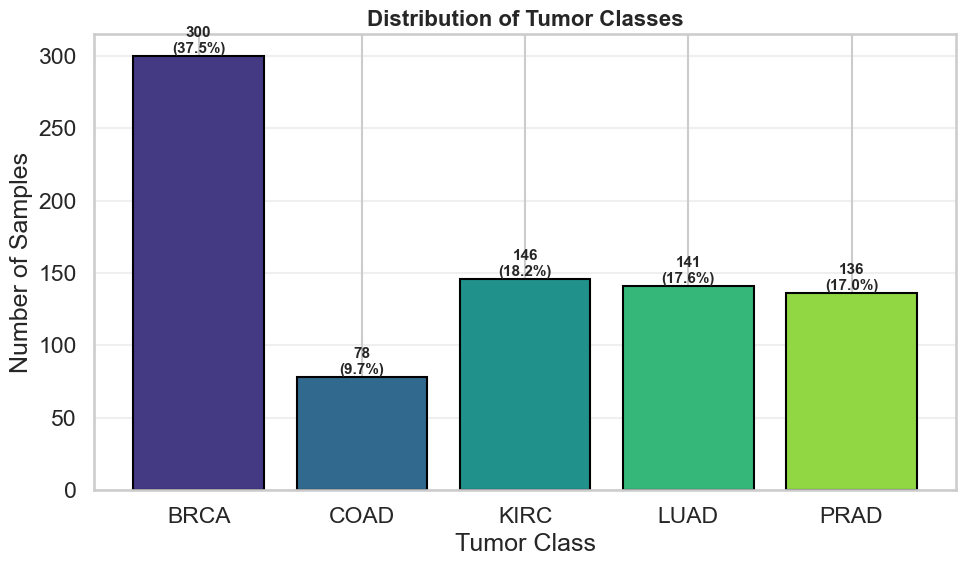

In [7]:
# 1.7 — EDA: class distribution
out_dir = Path('eda_outputs'); out_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))
order = y.value_counts().sort_index().index
counts = y.value_counts().sort_index().values
colors = sns.color_palette('viridis', len(order))
bars = ax.bar(order, counts, color=colors, edgecolor='black', linewidth=1.5)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h,
            f'{int(h)}\n({h / len(y) * 100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Tumor Classes', fontsize=16, fontweight='bold')
ax.set_xlabel('Tumor Class'); ax.set_ylabel('Number of Samples')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / '01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


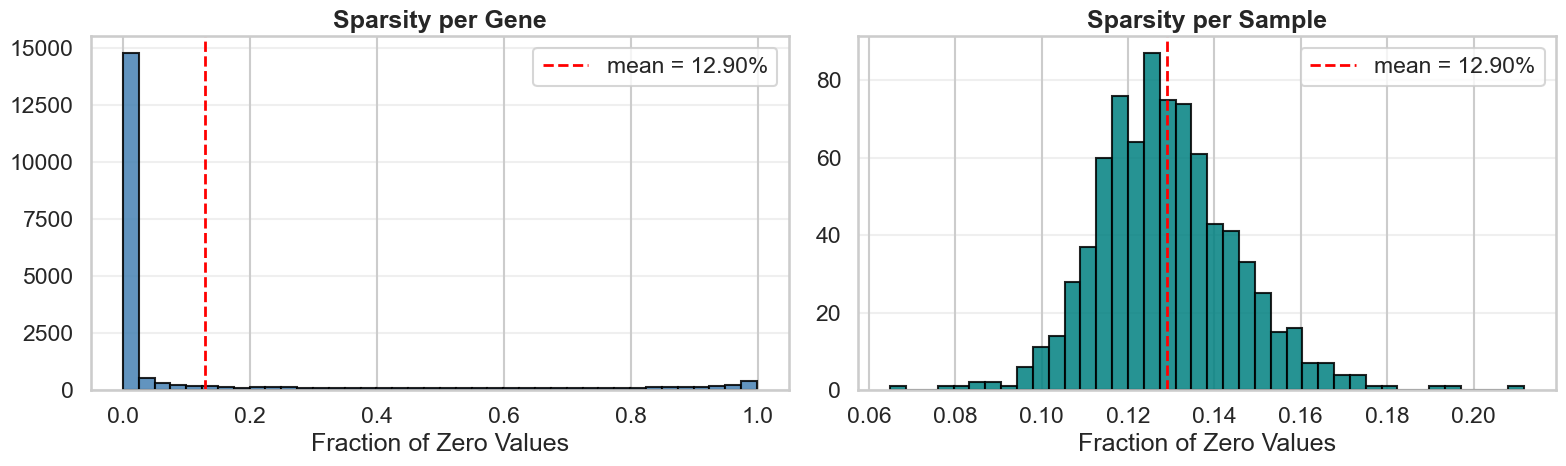

In [8]:
# 1.8 — EDA: sparsity (per gene & per sample)
zero_per_gene = (X == 0).mean()
zero_per_sample = (X == 0).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax_, data, title, color in [
    (axes[0], zero_per_gene,   'Sparsity per Gene',   'steelblue'),
    (axes[1], zero_per_sample, 'Sparsity per Sample', 'teal'),
]:
    ax_.hist(data, bins=40, color=color, edgecolor='black', alpha=0.85)
    ax_.axvline(data.mean(), color='red', ls='--', lw=2, label=f'mean = {data.mean():.2%}')
    ax_.set_title(title, fontweight='bold')
    ax_.set_xlabel('Fraction of Zero Values')
    ax_.legend(); ax_.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / '02_sparsity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Top 6 high-variance genes:
  1. gene_9176  (var=44.7638)
  2. gene_9175  (var=36.3619)
  3. gene_15898  (var=34.5039)
  4. gene_15301  (var=33.4588)
  5. gene_15589  (var=31.3258)
  6. gene_3540  (var=30.5877)


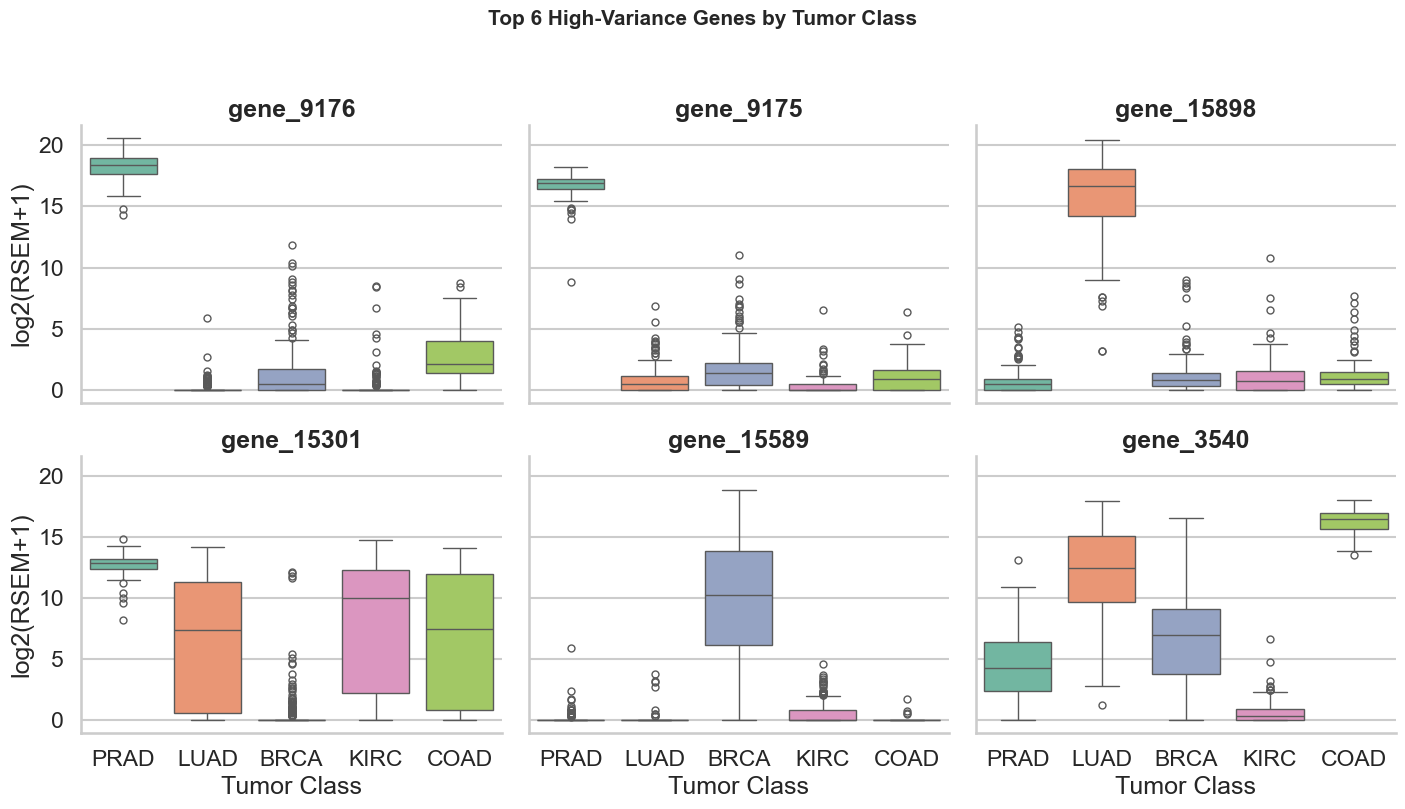

In [9]:
# 1.9 — EDA: top-variance genes by tumor class
top_var_genes = X.var().sort_values(ascending=False).head(6).index.tolist()
print('Top 6 high-variance genes:')
for i, g in enumerate(top_var_genes, 1):
    print(f'  {i}. {g}  (var={X[g].var():.4f})')

plot_rows = []
for g in top_var_genes:
    for cls in y.unique():
        for v in X.loc[y == cls, g]:
            plot_rows.append({'Gene': g, 'Tumor': cls, 'Expression': v})
plot_df = pd.DataFrame(plot_rows)

g_ = sns.catplot(data=plot_df, x='Tumor', y='Expression', col='Gene',
                 kind='box', col_wrap=3, height=4, aspect=1.2, palette='Set2')
g_.set_axis_labels('Tumor Class', 'log2(RSEM+1)')
g_.set_titles('{col_name}', fontweight='bold')
g_.fig.suptitle('Top 6 High-Variance Genes by Tumor Class', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(out_dir / '03_top_variance_genes.png', dpi=150, bbox_inches='tight')
plt.show()


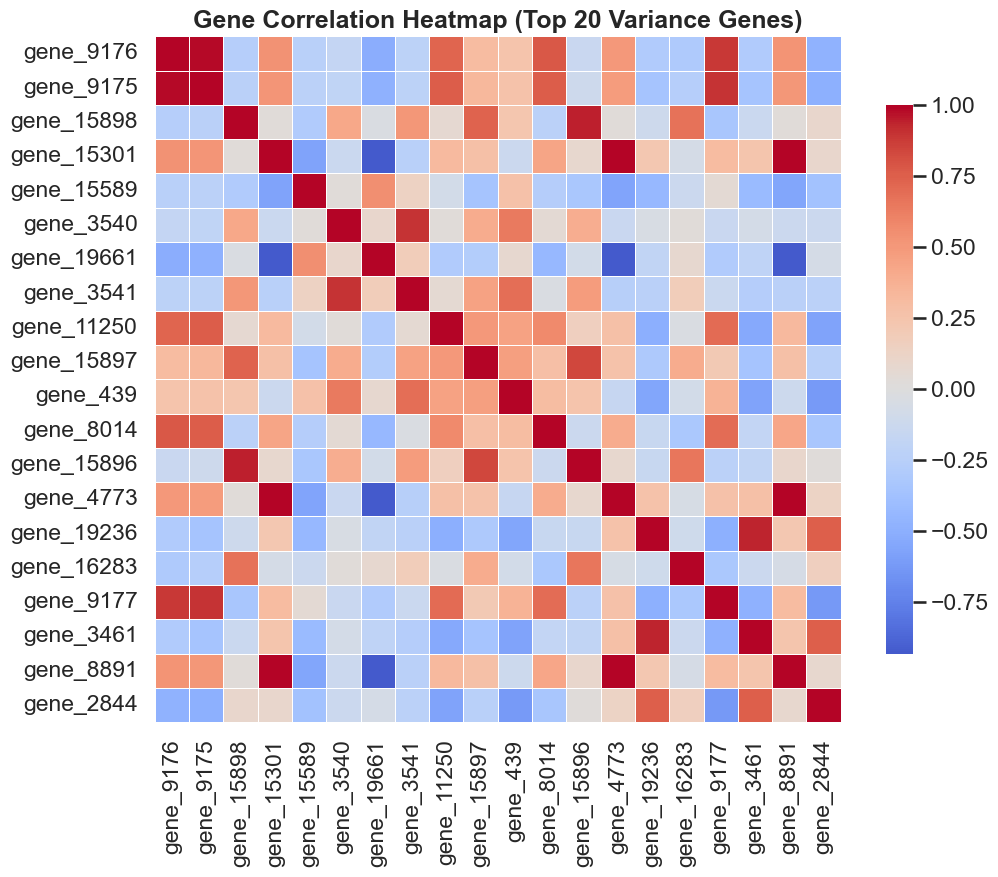

In [10]:
# 1.10 — EDA: gene correlation heatmap (top-20 variance genes)
top20 = X.var().sort_values(ascending=False).head(20).index.tolist()
corr = X[top20].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Gene Correlation Heatmap (Top 20 Variance Genes)', fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / '04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# 1.11 — Save Section 1 artefacts
X.to_csv('cleaned_features.csv')
y.to_csv('cleaned_labels.csv')

eda_summary = {
    'original_shape':           f'{df.shape[0]} samples x {len(gene_cols)} genes',
    'cleaned_shape':            f'{X.shape[0]} samples x {X.shape[1]} genes',
    'missing_values':           missing_total,
    'duplicate_rows':           duplicate_rows,
    'constant_genes_dropped':   len(constant_genes),
    'low_variance_genes_dropped': len(low_var_genes),
    'total_genes_removed':      len(genes_to_remove),
    'matrix_sparsity':          f'{sparsity:.2%}',
    'classes':                  sorted(y.unique().tolist()),
    'class_counts':             y.value_counts().to_dict(),
    'imbalance_ratio':          round(imbalance_ratio, 2),
}
with open('eda_summary.json', 'w') as fh:
    json.dump(eda_summary, fh, indent=2)

print('Section 1 complete.')
print('  cleaned_features.csv :', X.shape)
print('  cleaned_labels.csv   :', y.shape)
print('  eda_summary.json     : written')
print('  eda_outputs/*.png    : 4 figures')


Section 1 complete.
  cleaned_features.csv : (801, 20221)
  cleaned_labels.csv   : (801,)
  eda_summary.json     : written
  eda_outputs/*.png    : 4 figures


---
# SECTION 2 — Feature Engineering & Selection

**Goal:** Reduce 20,221 genes to a tractable feature set while keeping the discriminative signal between cancer types.

**Inputs:** `cleaned_features.csv`, `cleaned_labels.csv` from Section 1.

**Outputs:** `features_top{20,50,100,500}.csv`, `features_pca95.csv`, `anova_feature_stats.csv`, `kw_feature_stats.csv`, `scaler.pkl`, `pca_model.pkl`, `feature_outputs/*.png`.

### Why feature selection?
With p ≈ 20,000 genes and n = 801 samples, p ≫ n: most classifiers overfit immediately, and distance-based methods (KNN) collapse under the curse of dimensionality. We use a two-stage pipeline:

1. **Statistical filter** — ANOVA F-test per gene → BH-FDR correction → eta-squared effect size, validated against the non-parametric Kruskal-Wallis ranking. Used to build the top-K gene CSVs and for exploration.
2. **PCA on all cleaned genes** — 95% variance threshold. Decorrelates features, keeps full information, fits unsupervised so it does not see labels.

### Math reference
- **ANOVA F**:  F_g = [SS_between / (K-1)] / [SS_within / (N-K)]
- **BH-FDR**:   p̂_(i) = (m / i) · p_(i),  significant if p̂_(i) ≤ α
- **η²**:        SS_between / SS_total ∈ [0, 1]; ≥ 0.14 = large effect
- **Kruskal-Wallis H**:  H = [12 / (N(N+1))] · Σ_c R_c²/n_c − 3(N+1)
- **PCA**:      d* = argmin_d { Σ_{j≤d} λ_j / Σ_j λ_j ≥ 0.95 }


In [12]:
# 2.1 — Imports & load cleaned data
import joblib
from scipy.stats import f_oneway, kruskal, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests

X = pd.read_csv('cleaned_features.csv', index_col=0)
y = pd.read_csv('cleaned_labels.csv', index_col=0).squeeze()

feat_dir = Path('feature_outputs'); feat_dir.mkdir(exist_ok=True)
print(f'X: {X.shape}    y: {y.shape}    classes: {sorted(y.unique())}')


X: (801, 20221)    y: (801,)    classes: ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']


In [13]:
# 2.2 — ANOVA F-test for every gene
classes = sorted(y.unique())
overall_mean_per_gene = X.mean()

f_stats, p_values = [], []
for g in X.columns:
    groups = [X.loc[y == c, g].values for c in classes]
    f, p = f_oneway(*groups)
    f_stats.append(f); p_values.append(p)

anova = pd.DataFrame({'gene': X.columns, 'f_statistic': f_stats, 'p_value': p_values})
print(f'ANOVA F-tests computed for {len(anova):,} genes')


ANOVA F-tests computed for 20,221 genes


In [14]:
# 2.3 — Benjamini-Hochberg FDR correction
_, fdr, _, _ = multipletests(anova['p_value'], alpha=0.05, method='fdr_bh')
anova['fdr'] = fdr

sig_genes = int((anova['fdr'] < 0.05).sum())
print(f'genes significant at FDR < 0.05:  {sig_genes:,} / {len(anova):,}  ({sig_genes/len(anova)*100:.1f}%)')


genes significant at FDR < 0.05:  19,564 / 20,221  (96.8%)


In [15]:
# 2.4 — Eta-squared effect size
def eta_squared(values, labels):
    overall = values.mean()
    ss_total = ((values - overall) ** 2).sum()
    if ss_total == 0:
        return 0.0
    ss_between = sum(len(values[labels == c]) * (values[labels == c].mean() - overall) ** 2
                     for c in labels.unique())
    return ss_between / ss_total

anova['eta_squared'] = [eta_squared(X[g], y) for g in X.columns]
anova = anova.sort_values('fdr').reset_index(drop=True)
anova.to_csv('anova_feature_stats.csv', index=False)

large_effect = int((anova['eta_squared'] >= 0.14).sum())
print(f'genes with large effect (eta^2 >= 0.14): {large_effect:,} ({large_effect/len(anova)*100:.1f}%)')
print('\nTop-10 ANOVA-ranked genes:')
display(anova.head(10))


genes with large effect (eta^2 >= 0.14): 13,492 (66.7%)

Top-10 ANOVA-ranked genes:


,gene,f_statistic,p_value,fdr,eta_squared
0,gene_12808,1641.594019,0.0,0.0,0.891883
1,gene_7421,1986.246634,0.0,0.0,0.908935
2,gene_1510,1735.739602,0.0,0.0,0.897144
3,gene_13976,1728.637878,0.0,0.0,0.896765
4,gene_15898,1905.190879,0.0,0.0,0.905427
5,gene_16342,1586.479023,0.0,0.0,0.888545
6,gene_14503,1358.080059,0.0,0.0,0.872197
7,gene_19159,1269.364088,0.0,0.0,0.864475
8,gene_11566,1546.833428,0.0,0.0,0.886014
9,gene_12078,1157.534894,0.0,0.0,0.853303


In [16]:
# 2.5 — Kruskal-Wallis non-parametric validation
h_stats, kw_p = [], []
for g in X.columns:
    groups = [X.loc[y == c, g].values for c in classes]
    h, p = kruskal(*groups)
    h_stats.append(h); kw_p.append(p)

_, kw_fdr, _, _ = multipletests(kw_p, alpha=0.05, method='fdr_bh')
kw = pd.DataFrame({'gene': X.columns, 'h_statistic': h_stats, 'p_value': kw_p, 'fdr': kw_fdr})
kw = kw.sort_values('fdr').reset_index(drop=True)
kw.to_csv('kw_feature_stats.csv', index=False)

# Agreement between F and H rankings
merged = anova[['gene', 'f_statistic', 'fdr']].merge(
    kw[['gene', 'h_statistic']].rename(columns={'h_statistic': 'h'}), on='gene')
rho, _ = spearmanr(merged['f_statistic'], merged['h'])
print(f'Spearman correlation between ANOVA-F and KW-H: rho = {rho:.4f}')

overlap = {}
for k in (20, 50, 100, 500, 1000):
    a_top = set(anova.head(k)['gene']); k_top = set(kw.head(k)['gene'])
    overlap[k] = len(a_top & k_top) / k
print('Top-K overlap (ANOVA vs KW):')
for k, v in overlap.items():
    print(f'  K={k:>4}:  {v*100:5.1f}%')


Spearman correlation between ANOVA-F and KW-H: rho = 0.9815
Top-K overlap (ANOVA vs KW):
  K=  20:   20.0%
  K=  50:   16.0%
  K= 100:   26.0%
  K= 500:   54.8%
  K=1000:   68.7%


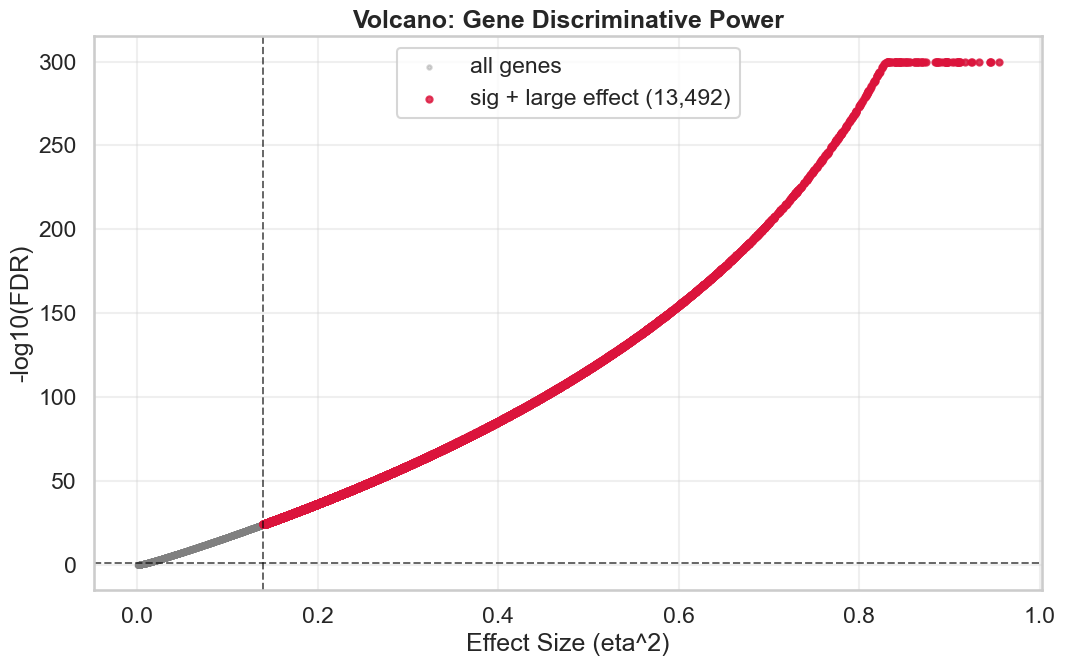

In [17]:
# 2.6 — Volcano plot (effect size vs -log10 FDR)
fig, ax = plt.subplots(figsize=(11, 7))
neglog_fdr = -np.log10(anova['fdr'] + 1e-300)
ax.scatter(anova['eta_squared'], neglog_fdr, s=10, alpha=0.3, color='gray', label='all genes')
mask = (anova['fdr'] < 0.05) & (anova['eta_squared'] >= 0.14)
ax.scatter(anova.loc[mask, 'eta_squared'], neglog_fdr[mask],
           s=20, alpha=0.8, color='crimson', label=f'sig + large effect ({int(mask.sum()):,})')
ax.axhline(-np.log10(0.05), ls='--', color='black', lw=1.4, alpha=0.6)
ax.axvline(0.14, ls='--', color='black', lw=1.4, alpha=0.6)
ax.set_xlabel('Effect Size (eta^2)'); ax.set_ylabel('-log10(FDR)')
ax.set_title('Volcano: Gene Discriminative Power', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(feat_dir / '01_anova_volcano.png', dpi=150, bbox_inches='tight')
plt.show()


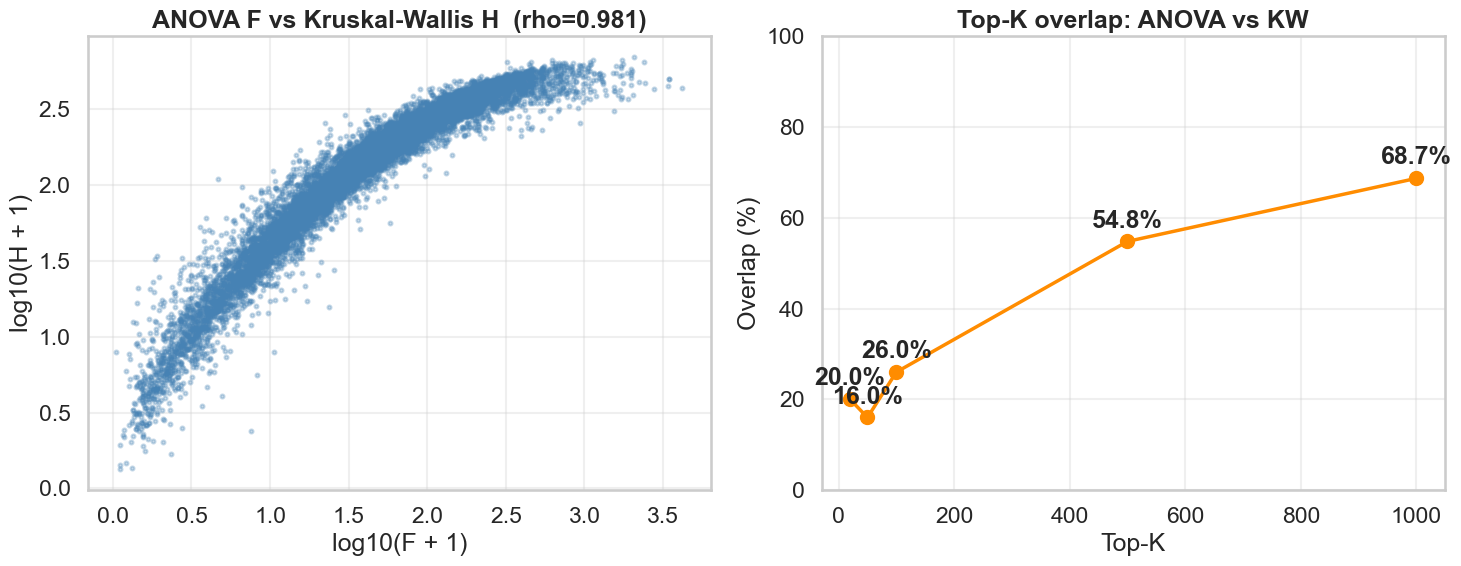

In [18]:
# 2.7 — ANOVA vs Kruskal-Wallis comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(np.log10(merged['f_statistic'] + 1), np.log10(merged['h'] + 1),
                s=8, alpha=0.3, color='steelblue')
axes[0].set_xlabel('log10(F + 1)'); axes[0].set_ylabel('log10(H + 1)')
axes[0].set_title(f'ANOVA F vs Kruskal-Wallis H  (rho={rho:.3f})', fontweight='bold')
axes[0].grid(alpha=0.3)

ks = list(overlap.keys())
axes[1].plot(ks, [overlap[k] * 100 for k in ks], 'o-', color='darkorange', lw=2.5, markersize=10)
axes[1].set_xlabel('Top-K'); axes[1].set_ylabel('Overlap (%)')
axes[1].set_title('Top-K overlap: ANOVA vs KW', fontweight='bold')
axes[1].set_ylim([0, 100]); axes[1].grid(alpha=0.3)
for k in ks:
    axes[1].annotate(f'{overlap[k]*100:.1f}%',
                     (k, overlap[k] * 100), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(feat_dir / '01b_anova_vs_kw.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# 2.8 — Save top-K feature subsets
selected = {}
for k in (20, 50, 100, 500):
    top_k = anova.head(k)['gene'].tolist()
    selected[k] = top_k
    X[top_k].to_csv(f'features_top{k}.csv')
    print(f'features_top{k:<4}.csv  ({k} genes)')

with open('selected_feature_sets.json', 'w') as fh:
    json.dump(selected, fh, indent=2)


features_top20  .csv  (20 genes)
features_top50  .csv  (50 genes)
features_top100 .csv  (100 genes)
features_top500 .csv  (500 genes)


In [20]:
# 2.9 — PCA on ALL cleaned genes -> 95% variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=RNG)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA components for 95% variance: {pca.n_components_}')
print(f'dimension reduction:             {(1 - pca.n_components_ / X.shape[1]) * 100:.1f}%')
print(f'PC1 variance: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'PC2 variance: {pca.explained_variance_ratio_[1]*100:.2f}%')


PCA components for 95% variance: 529
dimension reduction:             97.4%
PC1 variance: 10.56%
PC2 variance: 8.77%


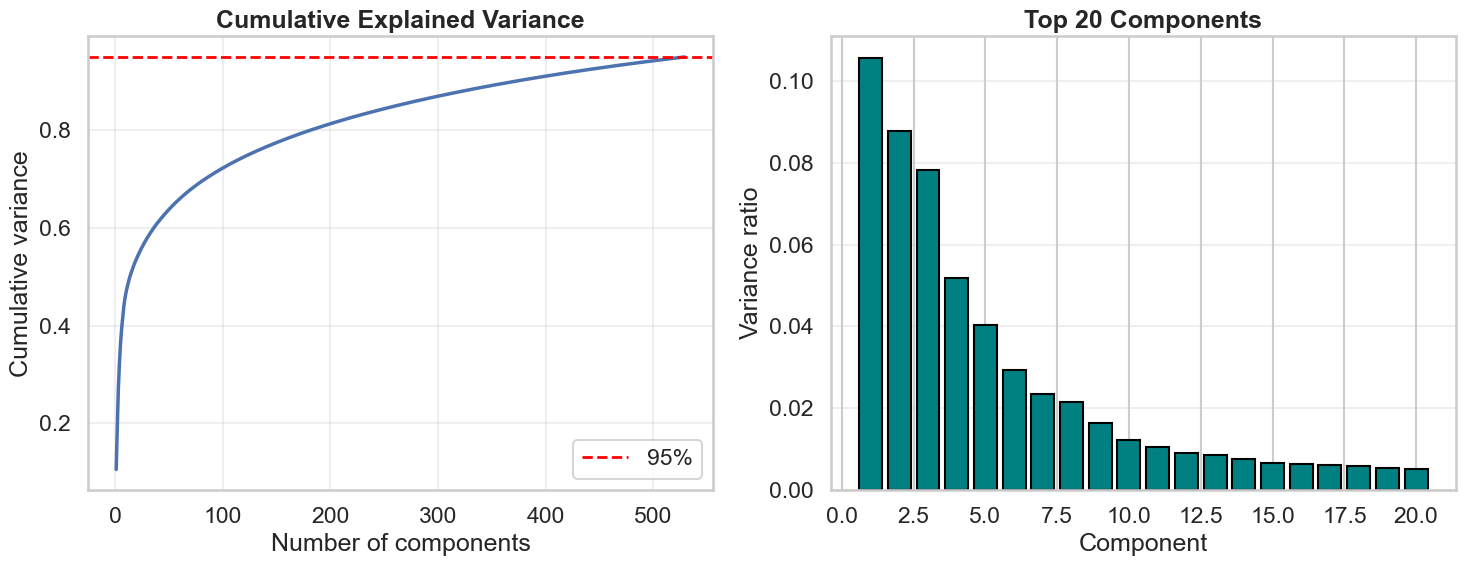

In [21]:
# 2.10 — PCA variance plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cumsum = np.cumsum(pca.explained_variance_ratio_)
axes[0].plot(range(1, len(cumsum) + 1), cumsum, lw=2.5)
axes[0].axhline(0.95, color='red', ls='--', lw=2, label='95%')
axes[0].set_xlabel('Number of components'); axes[0].set_ylabel('Cumulative variance')
axes[0].set_title('Cumulative Explained Variance', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar(range(1, 21), pca.explained_variance_ratio_[:20],
            color='teal', edgecolor='black')
axes[1].set_xlabel('Component'); axes[1].set_ylabel('Variance ratio')
axes[1].set_title('Top 20 Components', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(feat_dir / '02_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()


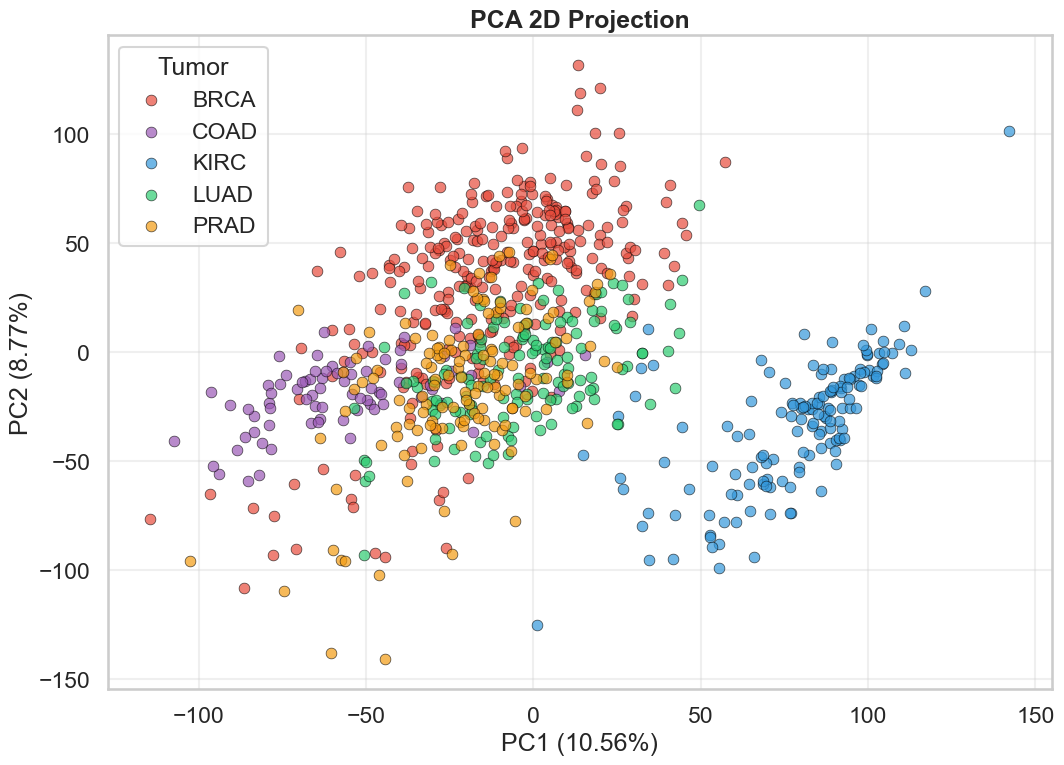

In [22]:
# 2.11 — PCA 2D scatter coloured by tumor class
pca_2d = PCA(n_components=2, random_state=RNG)
X_pca_2d = pca_2d.fit_transform(X_scaled)

palette = {'BRCA': '#e74c3c', 'KIRC': '#3498db', 'LUAD': '#2ecc71',
           'PRAD': '#f39c12', 'COAD': '#9b59b6'}

fig, ax = plt.subplots(figsize=(11, 8))
for cls in classes:
    m = (y == cls).values
    ax.scatter(X_pca_2d[m, 0], X_pca_2d[m, 1], label=cls, alpha=0.7, s=60,
               color=palette.get(cls, 'gray'), edgecolors='black', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)')
ax.set_title('PCA 2D Projection', fontweight='bold')
ax.legend(title='Tumor', loc='best'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(feat_dir / '03_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# 2.11b — PCA 3D scatter coloured by tumor class
from mpl_toolkits.mplot3d import Axes3D  # registers the 3d projection

pca_3d = PCA(n_components=3, random_state=RNG)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
for cls in classes:
    m = (y == cls).values
    ax.scatter(X_pca_3d[m, 0], X_pca_3d[m, 1], X_pca_3d[m, 2],
               label=cls, alpha=0.7, s=45,
               color=palette.get(cls, 'gray'),
               edgecolors='black', linewidth=0.4)
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.2f}%)', labelpad=10)
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.2f}%)', labelpad=10)
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.2f}%)', labelpad=10)
total_var = pca_3d.explained_variance_ratio_.sum() * 100
ax.set_title(f'PCA 3D Projection  (total: {total_var:.2f}%)',
             fontweight='bold', pad=18)
ax.legend(title='Tumor', loc='upper left')
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.savefig(feat_dir / '04_pca_3d.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
# 2.12 — Save Section 2 artefacts
pca_df = pd.DataFrame(X_pca, index=X.index,
                      columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df.to_csv('features_pca95.csv')

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca_model.pkl')

feature_summary = {
    'total_genes':                X.shape[1],
    'significant_genes_fdr_005':  sig_genes,
    'large_effect_genes_eta_014': large_effect,
    'top_20_genes':               selected[20],
    'pca_components_95var':       int(pca.n_components_),
    'pca_variance_pc1':           float(pca_2d.explained_variance_ratio_[0]),
    'pca_variance_pc2':           float(pca_2d.explained_variance_ratio_[1]),
    'pca_variance_pc3':           float(pca_3d.explained_variance_ratio_[2]),
    'pca_2d_total_variance':      float(pca_2d.explained_variance_ratio_.sum()),
    'pca_3d_total_variance':      float(pca_3d.explained_variance_ratio_.sum()),
    'spearman_anova_kw':          float(rho),
    'topk_overlap_anova_kw':      {str(k): float(v) for k, v in overlap.items()},
    'feature_sets_prepared':      [20, 50, 100, 500, 'PCA-95%'],
    'recommendation':             'use features_pca95.csv for modeling',
}
with open('feature_engineering_summary.json', 'w') as fh:
    json.dump(feature_summary, fh, indent=2)

print('Section 2 complete.')
print(f'  features_pca95.csv:    {pca_df.shape}')
print(f'  features_top{{20,50,100,500}}.csv')
print(f'  scaler.pkl, pca_model.pkl')
print(f'  feature_engineering_summary.json')


Section 2 complete.
  features_pca95.csv:    (801, 529)
  features_top{20,50,100,500}.csv
  scaler.pkl, pca_model.pkl
  feature_engineering_summary.json


---
# SECTION 3 — Model Training & Evaluation

**Goal:** Train and compare 8 classifiers on the PCA features, then tune the best one.

**Inputs:** `features_pca95.csv`, `cleaned_labels.csv`.

**Outputs:** `model_comparison_results.csv`, `hyperparameter_tuning_results.json`, `best_model_tuned.pkl`, `model_outputs/*.png`.

### Train-test split strategy
```
all 801 samples
    │
    ├─ stratified 80/20 split (random_state = RNG)
    │
    ├─ training set
    │     ├─ StandardScaler.fit
    │     ├─ 5-fold stratified CV
    │     └─ GridSearchCV on the winning model
    │
    └─ test set
          ├─ scaler.transform
          └─ final evaluation (reported once)
```

### Models compared
1. Logistic Regression (max_iter=2000)
2. Random Forest (n_estimators=100)
3. SVM with RBF kernel
4. SVM with Linear kernel
5. K-Nearest Neighbors (k=5) — expected to fail in 529-dim space (distance concentration)
6. Gradient Boosting (n_estimators=100, lr=0.1) — typically wins on TCGA data
7. Decision Tree
8. Gaussian Naive Bayes

### Metrics
- **CV Accuracy**: mean ± std across 5 folds.
- **Test Accuracy / Precision / Recall / F1**: weighted averages on the held-out 20%.
- **Confusion Matrix**: 5×5 with per-cell counts of true vs predicted class.


In [27]:
# 3.1 — Imports & load PCA features
import time
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

X = pd.read_csv('features_pca95.csv', index_col=0)
y = pd.read_csv('cleaned_labels.csv', index_col=0).squeeze()

model_dir = Path('model_outputs'); model_dir.mkdir(exist_ok=True)
print(f'X: {X.shape}    y: {y.shape}')


X: (801, 529)    y: (801,)


In [28]:
# 3.2 — Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG)

print(f'train: {X_train.shape}    test: {X_test.shape}')
print('train class counts:'); print(y_train.value_counts().sort_index())


train: (640, 529)    test: (161, 529)
train class counts:
tumor_class
BRCA    240
COAD     62
KIRC    116
LUAD    113
PRAD    109
Name: count, dtype: int64


In [29]:
# 3.3 — StandardScaler fitted on train only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f'train mean={X_train_s.mean():.4e}  std={X_train_s.std():.4f}')
print(f'test  mean={X_test_s.mean():.4e}   std={X_test_s.std():.4f}')


train mean=3.7777e-19  std=1.0000
test  mean=3.5927e-03   std=1.0175


In [30]:
# 3.4 — Define 8 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RNG),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RNG, n_jobs=-1),
    'SVM (RBF)':           SVC(kernel='rbf',    random_state=RNG, probability=True),
    'SVM (Linear)':        SVC(kernel='linear', random_state=RNG, probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=RNG),
    'Decision Tree':       DecisionTreeClassifier(random_state=RNG),
    'Naive Bayes':         GaussianNB(),
}
print(f'{len(models)} models initialised')


8 models initialised


In [31]:
# 3.5 — Train all models with 5-fold stratified CV + test evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
records = []
trained = {}

for name, model in models.items():
    t0 = time.time()
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=cv,
                                scoring='accuracy', n_jobs=-1)
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    elapsed = time.time() - t0

    rec = {
        'Model':            name,
        'CV_Accuracy_Mean': cv_scores.mean(),
        'CV_Accuracy_Std':  cv_scores.std(),
        'Test_Accuracy':    accuracy_score(y_test, y_pred),
        'Test_Precision':   precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Test_Recall':      recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'Test_F1':          f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'Training_Time':    elapsed,
    }
    records.append(rec)
    trained[name] = model
    print(f'{name:<22}  CV={rec["CV_Accuracy_Mean"]:.4f}  test={rec["Test_Accuracy"]:.4f}  '
          f'F1={rec["Test_F1"]:.4f}  ({elapsed:.1f}s)')

results = pd.DataFrame(records).sort_values('CV_Accuracy_Mean', ascending=False).reset_index(drop=True)
results.to_csv('model_comparison_results.csv', index=False)
results


Logistic Regression     CV=0.7953  test=0.8261  F1=0.8166  (8.4s)
Random Forest           CV=0.8703  test=0.8634  F1=0.8610  (3.4s)
SVM (RBF)               CV=0.5547  test=0.5342  F1=0.4511  (7.1s)
SVM (Linear)            CV=0.7969  test=0.8199  F1=0.8071  (2.8s)
K-Nearest Neighbors     CV=0.2891  test=0.2919  F1=0.2295  (0.5s)
Gradient Boosting       CV=0.9625  test=0.9565  F1=0.9557  (102.4s)
Decision Tree           CV=0.9016  test=0.8758  F1=0.8696  (1.0s)
Naive Bayes             CV=0.6875  test=0.6522  F1=0.6564  (0.2s)


,Model,CV_Accuracy_Mean,CV_Accuracy_Std,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Training_Time
0,Gradient Boosting,0.962500,0.020010,0.956522,0.957875,0.956522,0.955651,102.384028
1,Decision Tree,0.901563,0.033366,0.875776,0.884554,0.875776,0.869628,1.000888
2,Random Forest,0.870313,0.040323,0.863354,0.893720,0.863354,0.860964,3.378322
3,SVM (Linear),0.796875,0.027951,0.819876,0.873159,0.819876,0.807108,2.836526
4,Logistic Regression,0.795312,0.010364,0.826087,0.881423,0.826087,0.816601,8.403055
5,Naive Bayes,0.687500,0.046875,0.652174,0.675779,0.652174,0.656413,0.230715
6,SVM (RBF),0.554688,0.017116,0.534161,0.519669,0.534161,0.451114,7.131497
7,K-Nearest Neighbors,0.289062,0.028384,0.291925,0.522066,0.291925,0.229465,0.455810


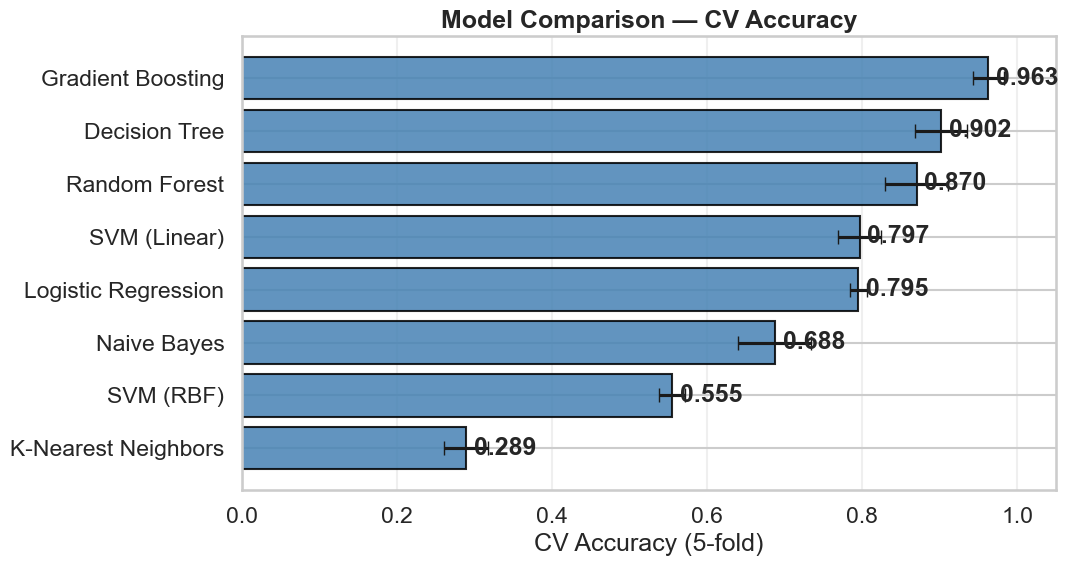

In [32]:
# 3.6 — Model comparison: CV accuracy bar chart
fig, ax = plt.subplots(figsize=(11, 6))
sorted_r = results.sort_values('CV_Accuracy_Mean')
ax.barh(sorted_r['Model'], sorted_r['CV_Accuracy_Mean'],
        xerr=sorted_r['CV_Accuracy_Std'], color='steelblue',
        edgecolor='black', alpha=0.85, capsize=5)
for i, (_, row) in enumerate(sorted_r.iterrows()):
    ax.text(row['CV_Accuracy_Mean'] + 0.01, i,
            f'{row["CV_Accuracy_Mean"]:.3f}', va='center', fontweight='bold')
ax.set_xlabel('CV Accuracy (5-fold)'); ax.set_xlim([0, 1.05])
ax.set_title('Model Comparison — CV Accuracy', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(model_dir / '01_model_comparison_cv.png', dpi=150, bbox_inches='tight')
plt.show()


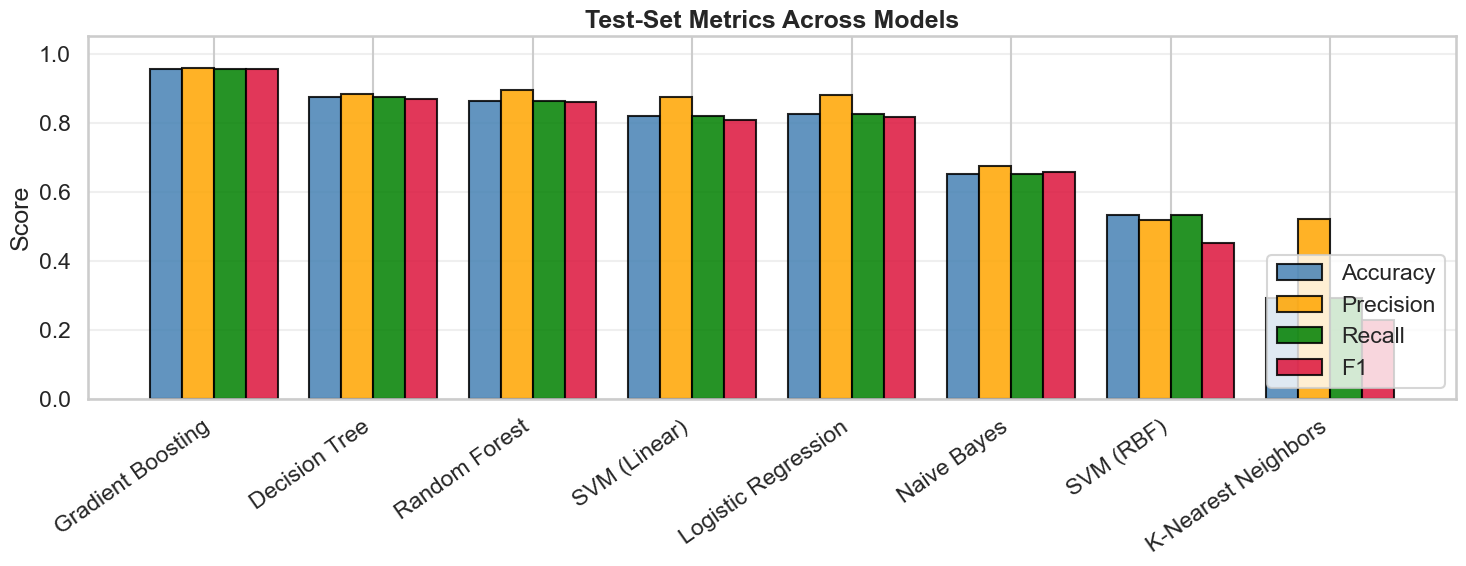

In [33]:
# 3.7 — Multi-metric comparison
metrics = ['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1']
fig, ax = plt.subplots(figsize=(15, 6))
xs = np.arange(len(results)); w = 0.2
colors = ['steelblue', 'orange', 'green', 'crimson']
for i, (m, c) in enumerate(zip(metrics, colors)):
    ax.bar(xs + i * w, results[m], w, label=m.replace('Test_', ''),
           color=c, alpha=0.85, edgecolor='black')
ax.set_xticks(xs + w * 1.5)
ax.set_xticklabels(results['Model'], rotation=35, ha='right')
ax.set_ylabel('Score'); ax.set_ylim([0, 1.05])
ax.set_title('Test-Set Metrics Across Models', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(model_dir / '02_model_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


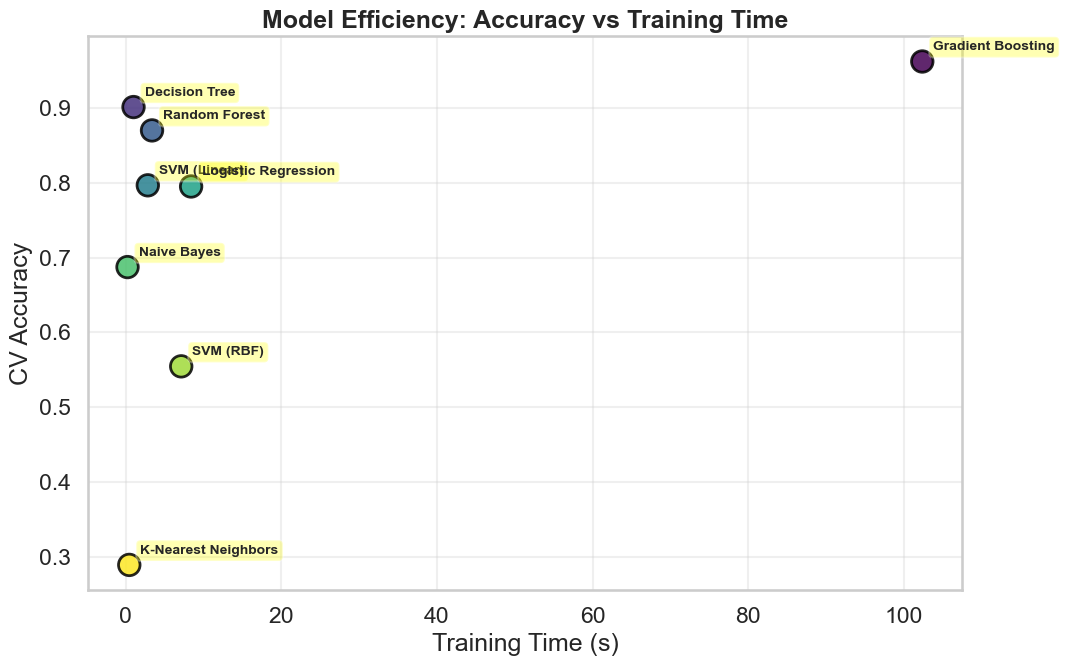

In [34]:
# 3.8 — Accuracy vs training time
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(results['Training_Time'], results['CV_Accuracy_Mean'],
           s=240, c=range(len(results)), cmap='viridis',
           alpha=0.85, edgecolors='black', linewidth=2)
for _, row in results.iterrows():
    ax.annotate(row['Model'], (row['Training_Time'], row['CV_Accuracy_Mean']),
                xytext=(8, 8), textcoords='offset points', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
ax.set_xlabel('Training Time (s)'); ax.set_ylabel('CV Accuracy')
ax.set_title('Model Efficiency: Accuracy vs Training Time', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(model_dir / '03_accuracy_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()


In [35]:
# 3.9 — Select best model
best_name = results.iloc[0]['Model']
best_cv   = results.iloc[0]['CV_Accuracy_Mean']
best_test = results.iloc[0]['Test_Accuracy']
print(f'BEST MODEL: {best_name}')
print(f'  CV accuracy:   {best_cv:.4f}')
print(f'  Test accuracy: {best_test:.4f}')


BEST MODEL: Gradient Boosting
  CV accuracy:   0.9625
  Test accuracy: 0.9565


In [36]:
# 3.10 — GridSearchCV hyperparameter tuning
param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear'], 'max_iter': [2000]},
    'Random Forest':       {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]},
    'SVM (RBF)':           {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.1]},
    'SVM (Linear)':        {'C': [0.1, 1, 10, 100]},
    'K-Nearest Neighbors': {'n_neighbors': [3, 5, 7, 9, 15], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']},
    'Gradient Boosting':   {'n_estimators': [50, 100, 200], 'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [3, 5]},
    'Decision Tree':       {'max_depth': [5, 10, 20, None], 'min_samples_split': [2, 5, 10], 'criterion': ['gini', 'entropy']},
    'Naive Bayes':         {'var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7]},
}
grid = param_grids[best_name]
print(f'Tuning {best_name} with grid:')
for k, v in grid.items():
    print(f'  {k}: {v}')

base = type(models[best_name])(**{p: getattr(models[best_name], p) for p in models[best_name].get_params()
                                   if p in models[best_name].get_params()})
gs = GridSearchCV(models[best_name], grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
gs.fit(X_train_s, y_train)

y_pred_tuned = gs.predict(X_test_s)
test_acc_tuned = accuracy_score(y_test, y_pred_tuned)

print(f'\nbest params:  {gs.best_params_}')
print(f'best CV score: {gs.best_score_:.4f}')
print(f'test accuracy before tuning: {best_test:.4f}')
print(f'test accuracy after  tuning: {test_acc_tuned:.4f}')
print(f'improvement:                 {test_acc_tuned - best_test:+.4f}')

joblib.dump(gs.best_estimator_, 'best_model_tuned.pkl')


Tuning Gradient Boosting with grid:
  n_estimators: [50, 100, 200]
  learning_rate: [0.05, 0.1, 0.2]
  max_depth: [3, 5]
Fitting 5 folds for each of 18 candidates, totalling 90 fits

best params:  {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
best CV score: 0.9688
test accuracy before tuning: 0.9565
test accuracy after  tuning: 0.9565
improvement:                 +0.0000


['best_model_tuned.pkl']

In [37]:
# 3.11 — Detailed classification report
print(f'Classification report ({best_name} tuned)\n')
print(classification_report(y_test, y_pred_tuned, digits=4))


Classification report (Gradient Boosting tuned)

              precision    recall  f1-score   support

        BRCA     0.9375    1.0000    0.9677        60
        COAD     0.8824    0.9375    0.9091        16
        KIRC     1.0000    0.9667    0.9831        30
        LUAD     0.9600    0.8571    0.9057        28
        PRAD     1.0000    0.9630    0.9811        27

    accuracy                         0.9565       161
   macro avg     0.9560    0.9449    0.9493       161
weighted avg     0.9581    0.9565    0.9562       161



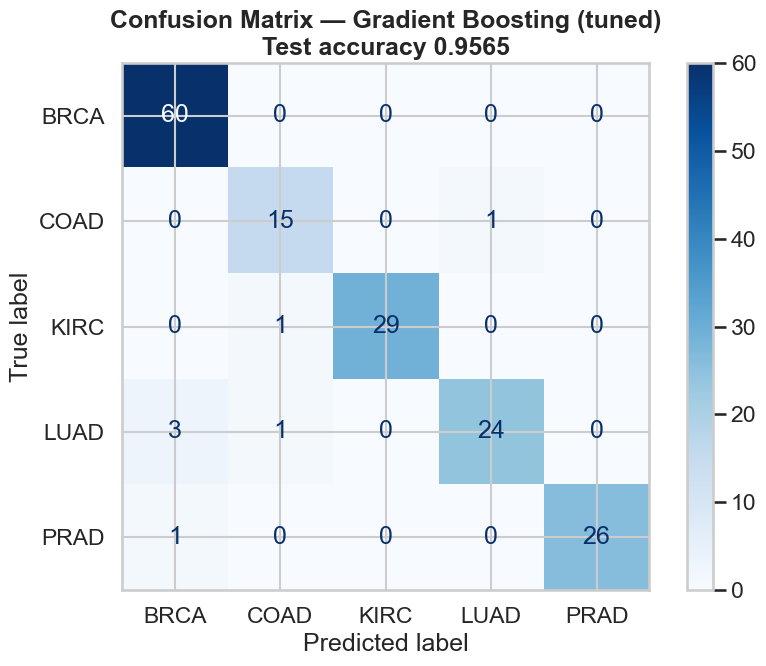

In [38]:
# 3.12 — Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned, labels=sorted(y.unique()))
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=sorted(y.unique()))
disp.plot(cmap='Blues', ax=ax, colorbar=True, values_format='d')
ax.set_title(f'Confusion Matrix — {best_name} (tuned)\nTest accuracy {test_acc_tuned:.4f}',
             fontweight='bold')
plt.tight_layout()
plt.savefig(model_dir / '04_confusion_matrix_tuned.png', dpi=150, bbox_inches='tight')
plt.show()


In [39]:
# 3.13 — Save tuning results
tuning_results = {
    'best_model':                  best_name,
    'best_params':                 gs.best_params_,
    'best_cv_score':               float(gs.best_score_),
    'test_accuracy_before_tuning': float(best_test),
    'test_accuracy_after_tuning':  float(test_acc_tuned),
    'improvement':                 float(test_acc_tuned - best_test),
}
with open('hyperparameter_tuning_results.json', 'w') as fh:
    json.dump(tuning_results, fh, indent=2)

print('Section 3 complete.')
print('  model_comparison_results.csv')
print('  hyperparameter_tuning_results.json')
print('  best_model_tuned.pkl')
print('  model_outputs/01-04_*.png')


Section 3 complete.
  model_comparison_results.csv
  hyperparameter_tuning_results.json
  best_model_tuned.pkl
  model_outputs/01-04_*.png
